In [18]:
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv('data.csv')
df.head()

,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
2,6,Trigun,Trigun,トライガン,8.22,"Action, Adventure, Sci-Fi","Vash the Stampede is the man with a $$60,000,0...",TV,26.0,"Apr 1, 1998 to Sep 30, 1998",...,Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),7.25,"Action, Drama, Mystery, Supernatural",Robin Sena is a powerful craft user drafted in...,TV,26.0,"Jul 3, 2002 to Dec 25, 2002",...,Sunrise,Original,25 min per ep,PG-13 - Teens 13 or older,2764.0,1795,613,42829.0,111931,https://cdn.myanimelist.net/images/anime/10/19...
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,6.94,"Adventure, Fantasy, Supernatural",It is the dark century and the people are suff...,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",...,Toei Animation,Manga,23 min per ep,PG - Children,4240.0,5126,14,6413.0,15001,https://cdn.myanimelist.net/images/anime/7/215...


In [20]:
# Change the column names to lowercase and remove blank spaces
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['anime_id', 'name', 'english_name', 'other_name', 'score', 'genres',
       'synopsis', 'type', 'episodes', 'aired', 'premiered', 'status',
       'producers', 'licensors', 'studios', 'source', 'duration', 'rating',
       'rank', 'popularity', 'favorites', 'scored_by', 'members', 'image_url'],
      dtype='str')

In [21]:
# Change the values in categorical columns to lowercase and remove blank spaces
categorical_columns = df.select_dtypes(include='str').columns
for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    
df[categorical_columns].head()

,name,english_name,other_name,score,genres,synopsis,type,episodes,aired,premiered,status,producers,licensors,studios,source,duration,rating,rank,scored_by,image_url
0,cowboy_bebop,cowboy_bebop,カウボーイビバップ,8.75,"action,_award_winning,_sci-fi","crime_is_timeless._by_the_year_2071,_humanity_...",tv,26.0,"apr_3,_1998_to_apr_24,_1999",spring_1998,finished_airing,bandai_visual,"funimation,_bandai_entertainment",sunrise,original,24_min_per_ep,r_-_17+_(violence_&_profanity),41.0,914193.0,https://cdn.myanimelist.net/images/anime/4/196...
1,cowboy_bebop:_tengoku_no_tobira,cowboy_bebop:_the_movie,カウボーイビバップ_天国の扉,8.38,"action,_sci-fi","another_day,_another_bounty—such_is_the_life_o...",movie,1.0,"sep_1,_2001",unknown,finished_airing,"sunrise,_bandai_visual",sony_pictures_entertainment,bones,original,1_hr_55_min,r_-_17+_(violence_&_profanity),189.0,206248.0,https://cdn.myanimelist.net/images/anime/1439/...
2,trigun,trigun,トライガン,8.22,"action,_adventure,_sci-fi","vash_the_stampede_is_the_man_with_a_$$60,000,0...",tv,26.0,"apr_1,_1998_to_sep_30,_1998",spring_1998,finished_airing,victor_entertainment,"funimation,_geneon_entertainment_usa",madhouse,manga,24_min_per_ep,pg-13_-_teens_13_or_older,328.0,356739.0,https://cdn.myanimelist.net/images/anime/7/203...
3,witch_hunter_robin,witch_hunter_robin,witch_hunter_robin_(ウイッチハンターロビン),7.25,"action,_drama,_mystery,_supernatural",robin_sena_is_a_powerful_craft_user_drafted_in...,tv,26.0,"jul_3,_2002_to_dec_25,_2002",summer_2002,finished_airing,"bandai_visual,_dentsu,_victor_entertainment,_t...","funimation,_bandai_entertainment",sunrise,original,25_min_per_ep,pg-13_-_teens_13_or_older,2764.0,42829.0,https://cdn.myanimelist.net/images/anime/10/19...
4,bouken_ou_beet,beet_the_vandel_buster,冒険王ビィト,6.94,"adventure,_fantasy,_supernatural",it_is_the_dark_century_and_the_people_are_suff...,tv,52.0,"sep_30,_2004_to_sep_29,_2005",fall_2004,finished_airing,"tv_tokyo,_dentsu",illumitoon_entertainment,toei_animation,manga,23_min_per_ep,pg_-_children,4240.0,6413.0,https://cdn.myanimelist.net/images/anime/7/215...


In [22]:
# We will have exactly one name column, so we will drop the other name column
df["english_name"] = np.where(df["english_name"] == "unknown", df["name"], df["english_name"])


In [23]:
# Columns to drop
columns_to_drop = ['name', "anime_id", "other_name", "synopsis", "image_url", "rank"]
df = df.drop(columns=columns_to_drop)

# Change column name
df = df.rename(columns={"english_name": "name"})
df.head()

,name,score,genres,type,episodes,aired,premiered,status,producers,licensors,studios,source,duration,rating,popularity,favorites,scored_by,members
0,cowboy_bebop,8.75,"action,_award_winning,_sci-fi",tv,26.0,"apr_3,_1998_to_apr_24,_1999",spring_1998,finished_airing,bandai_visual,"funimation,_bandai_entertainment",sunrise,original,24_min_per_ep,r_-_17+_(violence_&_profanity),43,78525,914193.0,1771505
1,cowboy_bebop:_the_movie,8.38,"action,_sci-fi",movie,1.0,"sep_1,_2001",unknown,finished_airing,"sunrise,_bandai_visual",sony_pictures_entertainment,bones,original,1_hr_55_min,r_-_17+_(violence_&_profanity),602,1448,206248.0,360978
2,trigun,8.22,"action,_adventure,_sci-fi",tv,26.0,"apr_1,_1998_to_sep_30,_1998",spring_1998,finished_airing,victor_entertainment,"funimation,_geneon_entertainment_usa",madhouse,manga,24_min_per_ep,pg-13_-_teens_13_or_older,246,15035,356739.0,727252
3,witch_hunter_robin,7.25,"action,_drama,_mystery,_supernatural",tv,26.0,"jul_3,_2002_to_dec_25,_2002",summer_2002,finished_airing,"bandai_visual,_dentsu,_victor_entertainment,_t...","funimation,_bandai_entertainment",sunrise,original,25_min_per_ep,pg-13_-_teens_13_or_older,1795,613,42829.0,111931
4,beet_the_vandel_buster,6.94,"adventure,_fantasy,_supernatural",tv,52.0,"sep_30,_2004_to_sep_29,_2005",fall_2004,finished_airing,"tv_tokyo,_dentsu",illumitoon_entertainment,toei_animation,manga,23_min_per_ep,pg_-_children,5126,14,6413.0,15001


In [24]:
df.dtypes

name            str
score           str
genres          str
type            str
episodes        str
aired           str
premiered       str
status          str
producers       str
licensors       str
studios         str
source          str
duration        str
rating          str
popularity    int64
favorites     int64
scored_by       str
members       int64
dtype: object

In [25]:
len(df)

24905

In [26]:
# Columns need to be converted to numeric
numeric_columns = ['episodes', 'score', 'scored_by']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

df = df.dropna(subset=["score", "episodes"])
df.dtypes

name              str
score         float64
genres            str
type              str
episodes      float64
aired             str
premiered         str
status            str
producers         str
licensors         str
studios           str
source            str
duration          str
rating            str
popularity      int64
favorites       int64
scored_by     float64
members         int64
dtype: object

In [27]:
len(df)

15604

In [31]:
df.isnull().sum()

name          0
score         0
genres        0
type          0
episodes      0
aired         0
premiered     0
status        0
producers     0
licensors     0
studios       0
source        0
duration      0
rating        0
popularity    0
favorites     0
scored_by     0
members       0
dtype: int64

In [32]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n_train, n_val, n_test

(9364, 3120, 3120)

In [35]:
# Split the data into train, validation, and test sets
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()
df_test = df.iloc[idx[n_train+n_val:]].copy()

In [36]:
df_train.head()

,name,score,genres,type,episodes,aired,premiered,status,producers,licensors,studios,source,duration,rating,popularity,favorites,scored_by,members
2948,fashion_lala:_the_story_of_the_harbour_light,5.21,unknown,ova,1.0,"mar_11,_1988",unknown,finished_airing,unknown,unknown,pierrot,original,48_min,pg-13_-_teens_13_or_older,10538,1,772.0,2086
2613,accelerando:_datenshi-tachi_no_sasayaki,6.82,hentai,ova,4.0,"jan_26,_2007_to_feb_26,_2010",unknown,finished_airing,pink_pineapple,unknown,"flavors_soft,_maboroshi_koubou",manga,28_min_per_ep,rx_-_hentai,5400,47,5437.0,13231
1050,e.y.e.s._of_mars,5.44,"adventure,_drama,_sci-fi",movie,1.0,"dec_26,_1993",unknown,finished_airing,unknown,unknown,toei_animation,unknown,1_hr_15_min,pg-13_-_teens_13_or_older,11470,2,512.0,1492
2281,onegai_my_melody,7.27,"comedy,_fantasy",tv,52.0,"apr_3,_2005_to_mar_26,_2006",spring_2005,finished_airing,"tv_osaka,_sanrio,_yomiuri_advertising",unknown,studio_comet,unknown,24_min_per_ep,pg_-_children,5135,182,4239.0,14941
6549,kami_nomi_zo_shiru_sekai:_natsu-iro_surprise,6.52,unknown,music,1.0,"sep_14,_2011",unknown,finished_airing,unknown,unknown,manglobe,manga,2_min,pg-13_-_teens_13_or_older,6078,6,4802.0,9868


In [37]:
# Reset the indices of the train, validation, and test sets
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head()

,name,score,genres,type,episodes,aired,premiered,status,producers,licensors,studios,source,duration,rating,popularity,favorites,scored_by,members
0,fashion_lala:_the_story_of_the_harbour_light,5.21,unknown,ova,1.0,"mar_11,_1988",unknown,finished_airing,unknown,unknown,pierrot,original,48_min,pg-13_-_teens_13_or_older,10538,1,772.0,2086
1,accelerando:_datenshi-tachi_no_sasayaki,6.82,hentai,ova,4.0,"jan_26,_2007_to_feb_26,_2010",unknown,finished_airing,pink_pineapple,unknown,"flavors_soft,_maboroshi_koubou",manga,28_min_per_ep,rx_-_hentai,5400,47,5437.0,13231
2,e.y.e.s._of_mars,5.44,"adventure,_drama,_sci-fi",movie,1.0,"dec_26,_1993",unknown,finished_airing,unknown,unknown,toei_animation,unknown,1_hr_15_min,pg-13_-_teens_13_or_older,11470,2,512.0,1492
3,onegai_my_melody,7.27,"comedy,_fantasy",tv,52.0,"apr_3,_2005_to_mar_26,_2006",spring_2005,finished_airing,"tv_osaka,_sanrio,_yomiuri_advertising",unknown,studio_comet,unknown,24_min_per_ep,pg_-_children,5135,182,4239.0,14941
4,kami_nomi_zo_shiru_sekai:_natsu-iro_surprise,6.52,unknown,music,1.0,"sep_14,_2011",unknown,finished_airing,unknown,unknown,manglobe,manga,2_min,pg-13_-_teens_13_or_older,6078,6,4802.0,9868


In [38]:
# Create the target variable
y_train = df_train.score.values
y_val = df_val.score.values
y_test = df_test.score.values

In [39]:
del df_train['score']
del df_val['score']
del df_test['score']

In [40]:
len(y_train), len(y_val), len(y_test)

(9364, 3120, 3120)

In [41]:
categorical_columns = df_train.select_dtypes(include='str').columns.tolist()

categories = {}

for col in categorical_columns:
    categories[col] = list(df_train[col].value_counts().head().index)
    
categories

{'name': ['cyborg_009',
  'ling_cage',
  'tenchi_muyo!_ryo-ohki',
  'outlaw_star',
  'digimon_fusion'],
 'genres': ['unknown', 'comedy', 'hentai', 'fantasy', 'action,_sci-fi'],
 'type': ['tv', 'ova', 'movie', 'special', 'ona'],
 'aired': ['2008', '2005', '2003', '2004', '2009'],
 'premiered': ['unknown',
  'fall_2016',
  'spring_2006',
  'spring_2018',
  'spring_2016'],
 'status': ['finished_airing', 'currently_airing'],
 'producers': ['unknown', 'pink_pineapple', 'nhk', 'aniplex', 'bandai_visual'],
 'licensors': ['unknown',
  'funimation',
  'sentai_filmworks',
  'discotek_media',
  'aniplex_of_america'],
 'studios': ['unknown', 'toei_animation', 'sunrise', 'j.c.staff', 'madhouse'],
 'source': ['original', 'manga', 'unknown', 'visual_novel', 'game'],
 'duration': ['24_min_per_ep',
  '23_min_per_ep',
  '25_min_per_ep',
  '3_min',
  '4_min'],
 'rating': ['pg-13_-_teens_13_or_older',
  'g_-_all_ages',
  'rx_-_hentai',
  'r_-_17+_(violence_&_profanity)',
  'r+_-_mild_nudity']}

In [42]:
# Get numerical columns
base_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
base_features

['episodes', 'popularity', 'favorites', 'scored_by', 'members']

In [44]:
def prepare_X(df):
    df = df.copy()
    features = base_features.copy()
    
    for c, values in categories.items():
        for v in values:
            name = f"{c}_{v}"
            df[name] = (df[c] == v).astype(int)
            features.append(name)
        del df[c]
    
    df[features] = df[features].fillna(0)
        
    X = df[features].values
    return X

In [45]:
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

In [48]:
def train_linear_regression(X, y, alpha = 0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX += alpha * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [49]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.6080676422370124)

In [50]:
# We will try to find  the best value of alpha by trying different values and checking the RMSE value for each one.
for alpha in [0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train, alpha)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + np.dot(X_val, w)
    
    print(f"alpha: {alpha}, RMSE: {rmse(y_val, y_pred)}")

alpha: 0.0, RMSE: 13.513895484228852
alpha: 1e-05, RMSE: 0.6080674143547414
alpha: 0.0001, RMSE: 0.6080674518778181
alpha: 0.001, RMSE: 0.6080676422370124
alpha: 0.01, RMSE: 0.608069578714259
alpha: 0.1, RMSE: 0.6080896960312258
alpha: 1, RMSE: 0.6083534293442062
alpha: 10, RMSE: 0.6129358710422979


#### Full Train

In [51]:
df_full_train = pd.concat([df_train, df_val], ignore_index=True)
X_full_train = prepare_X(df_full_train)
X_full_train

array([[1.0000e+00, 1.0538e+04, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0000e+00, 5.4000e+03, 4.7000e+01, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 1.1470e+04, 2.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       ...,
       [1.0000e+00, 1.4386e+04, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.2000e+01, 1.3700e+02, 1.6063e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [1.0000e+00, 1.5444e+04, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(12484, 62))

In [52]:
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression(X_full_train, y_full_train, alpha=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

np.float64(0.6021813569979568)

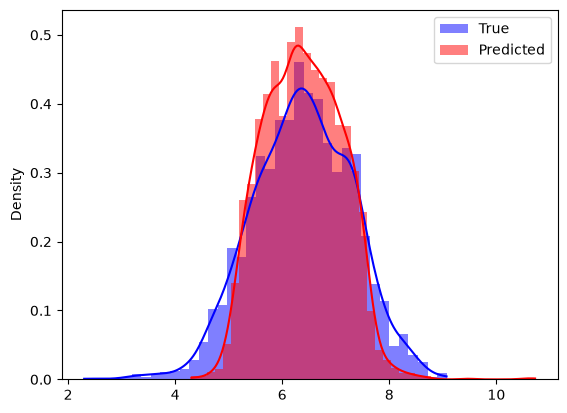

In [54]:
# Visualize this 
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_test, label='True', color='blue', kde=True, stat="density", linewidth=0)
sns.histplot(y_pred, label='Predicted', color='red', kde=True, stat="density", linewidth=0)
plt.legend()


#### Check for one anime

In [55]:
steins_gate = df_test[df_test.name == "steins;gate"].to_dict(orient='records')[0]
steins_gate

{'name': 'steins;gate',
 'genres': 'drama,_sci-fi,_suspense',
 'type': 'tv',
 'episodes': 24.0,
 'aired': 'apr_6,_2011_to_sep_14,_2011',
 'premiered': 'spring_2011',
 'status': 'finished_airing',
 'producers': 'frontier_works,_media_factory,_kadokawa_shoten,_movic,_at-x,_kadokawa_pictures_japan,_nitroplus',
 'licensors': 'funimation',
 'studios': 'white_fox',
 'source': 'visual_novel',
 'duration': '24_min_per_ep',
 'rating': 'pg-13_-_teens_13_or_older',
 'popularity': 13,
 'favorites': 182964,
 'scored_by': 1336233.0,
 'members': 2440369}

In [56]:
df_steins_gate = pd.DataFrame([steins_gate])
df_steins_gate

,name,genres,type,episodes,aired,premiered,status,producers,licensors,studios,source,duration,rating,popularity,favorites,scored_by,members
0,steins;gate,"drama,_sci-fi,_suspense",tv,24.0,"apr_6,_2011_to_sep_14,_2011",spring_2011,finished_airing,"frontier_works,_media_factory,_kadokawa_shoten...",funimation,white_fox,visual_novel,24_min_per_ep,pg-13_-_teens_13_or_older,13,182964,1336233.0,2440369


In [57]:
X_steins_gate = prepare_X(df_steins_gate)
y_pred_steins_gate = w0 + X_steins_gate.dot(w)
y_pred_steins_gate

array([10.5460108])

In [59]:
# Check the actual score of Steins;Gate in the test set
actual_score_steins_gate = df[df.name == "steins;gate"].score.values[0]
actual_score_steins_gate

np.float64(9.07)

#### We need to set boundaries for the predicted scores. The score should be between 0 and 10.m

In [60]:
def predict(X, w0, w):
    y_pred = w0 + X.dot(w)
    return np.clip(y_pred, 0, 10)

In [61]:
# Lets see the model again
X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression(X_full_train, y_full_train, alpha=0.001)

X_test = prepare_X(df_test)
y_pred = predict(X_test, w0, w)

rmse(y_test, y_pred)

np.float64(0.6013225649816661)

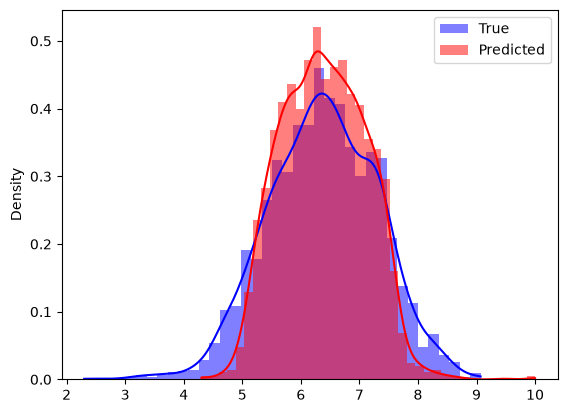

In [62]:
# Visualize this 
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_test, label='True', color='blue', kde=True, stat="density", linewidth=0)
sns.histplot(y_pred, label='Predicted', color='red', kde=True, stat="density", linewidth=0)
plt.legend()
